# Lesson 2.2 - Calculus & Optimization for AI

## Objectives
- Connect derivatives/gradients to optimization behavior.
- Visualize loss landscapes and learning-rate effects.
- Train a tiny linear model via gradient descent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

## Section A - Derivative vs Numerical Approximation

In [2]:
def f(x: np.ndarray | float):
    return x**2 + 0.5 * x


def grad_f(x: np.ndarray | float):
    return 2 * x + 0.5


def numerical_grad(func, x: float, eps: float = 1e-6) -> float:
    return float((func(x + eps) - func(x - eps)) / (2 * eps))


for p in [-2.0, 0.0, 3.0]:
    print(p, "analytic:", grad_f(p), "numeric:", round(numerical_grad(f, p), 6))

-2.0 analytic: -3.5 numeric: -3.5
0.0 analytic: 0.5 numeric: 0.5
3.0 analytic: 6.5 numeric: 6.5


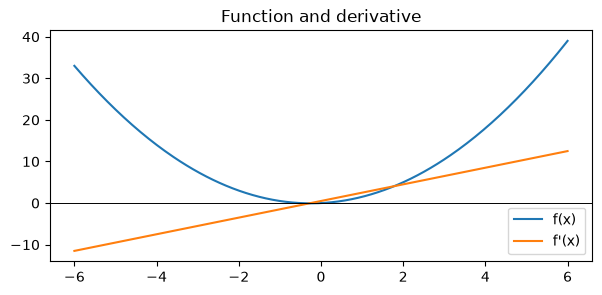

In [3]:
xs = np.linspace(-6, 6, 300)
plt.figure(figsize=(7, 3))
plt.plot(xs, f(xs), label="f(x)")
plt.plot(xs, grad_f(xs), label="f'(x)")
plt.axhline(0, color="black", linewidth=0.7)
plt.legend()
plt.title("Function and derivative")
plt.show()

## Section B - Gradient Descent and Learning-Rate Effects

In [4]:
def gd_1d(grad, x0: float, lr: float, steps: int = 50):
    path = [x0]
    for _ in range(steps):
        x0 = x0 - lr * grad(x0)
        path.append(x0)
    return path


lr_paths = {
    0.01: gd_1d(grad_f, x0=8.0, lr=0.01, steps=80),
    0.1: gd_1d(grad_f, x0=8.0, lr=0.1, steps=80),
    0.8: gd_1d(grad_f, x0=8.0, lr=0.8, steps=30),
}

for lr, path in lr_paths.items():
    print("lr", lr, "final x", round(path[-1], 4), "final f(x)", round(float(f(path[-1])), 6))

lr 0.01 final x 1.3889 final f(x) 2.623339
lr 0.1 final x -0.25 final f(x) -0.0625
lr 0.8 final x -0.25 final f(x) -0.0625


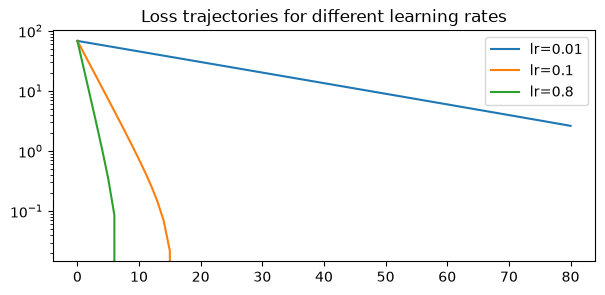

In [5]:
plt.figure(figsize=(7, 3))
for lr, path in lr_paths.items():
    losses = [f(x) for x in path]
    plt.plot(losses, label=f"lr={lr}")
plt.yscale("log")
plt.legend()
plt.title("Loss trajectories for different learning rates")
plt.show()

## Section C - 2D Loss Surface (Textbook Visualization)

We inspect a convex bowl: L(w1, w2)=w1^2+2*w2^2.

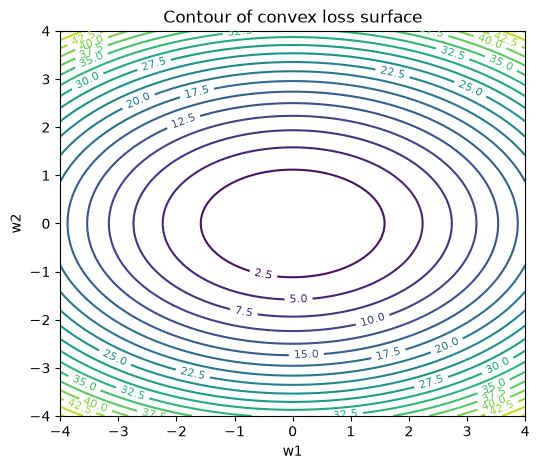

In [6]:
w1 = np.linspace(-4, 4, 120)
w2 = np.linspace(-4, 4, 120)
W1, W2 = np.meshgrid(w1, w2)
L = W1**2 + 2 * W2**2

plt.figure(figsize=(6, 5))
cs = plt.contour(W1, W2, L, levels=20)
plt.clabel(cs, inline=True, fontsize=8)
plt.title("Contour of convex loss surface")
plt.xlabel("w1")
plt.ylabel("w2")
plt.show()

## Section D - Gradient Descent on Linear Regression

In [7]:
X = np.linspace(0, 10, 150)
y = 2.7 * X + 4.2 + np.random.normal(scale=1.5, size=X.shape[0])


def mse(Xv: np.ndarray, yv: np.ndarray, w: float, b: float) -> float:
    pred = w * Xv + b
    return float(np.mean((pred - yv) ** 2))


def grad_w_b(Xv: np.ndarray, yv: np.ndarray, w: float, b: float):
    pred = w * Xv + b
    err = pred - yv
    dw = (2 / len(Xv)) * np.dot(err, Xv)
    db = (2 / len(Xv)) * err.sum()
    return float(dw), float(db)


def train_linear_gd(Xv: np.ndarray, yv: np.ndarray, lr: float = 0.01, epochs: int = 2500):
    if lr <= 0:
        raise ValueError("learning rate must be positive")
    w, b = 0.0, 0.0
    hist = []
    for _ in range(epochs):
        dw, db = grad_w_b(Xv, yv, w, b)
        w -= lr * dw
        b -= lr * db
        hist.append(mse(Xv, yv, w, b))
    return w, b, hist


w_hat, b_hat, hist = train_linear_gd(X, y, lr=0.01, epochs=3000)
print("w_hat:", round(w_hat, 4), "b_hat:", round(b_hat, 4), "final_loss:", round(hist[-1], 4))

w_hat: 2.7112 b_hat: 4.3322 final_loss: 2.341


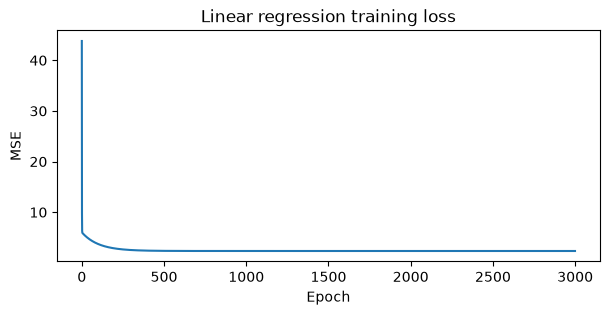

In [8]:
plt.figure(figsize=(7, 3))
plt.plot(hist)
plt.title("Linear regression training loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

## Business Case Studies & Exceptions
- Too-high learning rates can cause retraining divergence and missed SLAs.
- Feature scaling often improves convergence speed significantly.
- Exception: if warm-starting from prior parameters, more aggressive schedules may be safe.

## Interview Questions & Answers
1. What does gradient represent? Direction of steepest increase of loss.
2. Why does chain rule matter? It enables backpropagation through composed functions.